In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Prepare Your Dataset for ResNet Fine-tuning

This section extracts labels from your JSON files, splits the data into training, validation, and test sets, and sets up `ImageDataGenerator` objects to efficiently load and augment your images for the ResNet model.

In [ ]:
import os
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Define the base path to your dataset in Google Drive
input_base_dir = '/content/drive/MyDrive/allimages/gen_img/'

# List to store extracted data
image_data = []

# Iterate through the directory structure to find JSON files
print(f"Scanning '{input_base_dir}' for JSON files and corresponding images...")
for root, dirs, files in os.walk(input_base_dir):
    for filename in files:
        if filename.endswith('.json'):
            json_file_path = os.path.join(root, filename)

            try:
                with open(json_file_path, 'r') as f:
                    data = json.load(f)

                image_file_name_from_json = data.get('filename') # This could be 'image.png' or just 'image'

                # Extract base name from JSON filename or JSON file path
                if image_file_name_from_json:
                    image_base_name = os.path.splitext(image_file_name_from_json)[0]
                else:
                    image_base_name = os.path.splitext(os.path.basename(json_file_path))[0]

                image_relative_dir = os.path.relpath(root, input_base_dir)

                found_image_path = None

                # 1. Try the exact filename from JSON if it exists
                if image_file_name_from_json:
                    candidate_path = os.path.join(input_base_dir, image_relative_dir, image_file_name_from_json)
                    if os.path.exists(candidate_path):
                        found_image_path = candidate_path

                # 2. If not found, try common extensions
                if not found_image_path:
                    candidate_png_path = os.path.join(input_base_dir, image_relative_dir, image_base_name + '.png')
                    if os.path.exists(candidate_png_path):
                        found_image_path = candidate_png_path
                    else:
                        candidate_jpg_path = os.path.join(input_base_dir, image_relative_dir, image_base_name + '.jpg')
                        if os.path.exists(candidate_jpg_path):
                            found_image_path = candidate_jpg_path
                        else:
                            candidate_jpeg_path = os.path.join(input_base_dir, image_relative_dir, image_base_name + '.jpeg')
                            if os.path.exists(candidate_jpeg_path):
                                found_image_path = candidate_jpeg_path

                if found_image_path:
                    # Extract labels
                    has_ramp = data.get('has_ramp', False)
                    has_disabled_parking = data.get('has_disabled_parking', False)
                    has_stairs = False
                    if data.get('scenario') == 'stairs_only' or ('stairs' in data.get('scenario_label', '').lower() and 'ramp' not in data.get('scenario_label', '').lower()):
                        has_stairs = True

                    image_data.append({
                        'image_path': found_image_path,
                        'has_stairs': has_stairs,
                        'has_ramp': has_ramp,
                        'has_disabled_parking': has_disabled_parking
                    })
                else:
                    print(f"Warning: Image file not found for JSON '{json_file_path}' (tried '{image_base_name}.png', '{image_base_name}.jpg', '{image_base_name}.jpeg', or original filename). Skipping this entry.")

            except Exception as e:
                print(f"Error processing {json_file_path}: {e}")

df_labels = pd.DataFrame(image_data)

print(f"\nExtracted labels for {len(df_labels)} images that have existing image files.")

Scanning '/content/drive/MyDrive/allimages/gen_img/' for JSON files and corresponding images...

Extracted labels for 1693 images that have existing image files.


### Re-splitting Data and Recreating Generators

Since the `input_base_dir` was updated, the dataframes derived from `df_labels` need to be recreated to reflect the correct image paths. We will re-run the data splitting and `ImageDataGenerator` creation cells to resolve the 'image not found' warnings.

In [ ]:
# Define the labels (target variables) for our multi-label classification
labels = ['has_stairs', 'has_ramp', 'has_disabled_parking']

# Split the data into training and a temporary set (validation + test)
X = df_labels['image_path']
y = df_labels[labels]

# Using stratify=y for multi-label can be tricky if some label combinations are rare.
# For simplicity, we'll remove it for now, but be aware of potential imbalances.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Create DataFrames for each split
df_train = pd.DataFrame({'image_path': X_train, 'labels': y_train.values.tolist()}).reset_index(drop=True)
df_val = pd.DataFrame({'image_path': X_val, 'labels': y_val.values.tolist()}).reset_index(drop=True)
df_test = pd.DataFrame({'image_path': X_test, 'labels': y_test.values.tolist()}).reset_index(drop=True)

# For `flow_from_dataframe`, `y_col` expects column names, not a single list column.
# So, let's expand the 'labels' list into separate columns in the DataFrame.
def expand_labels(df, original_labels_col_name='labels', target_names=labels):
    temp_labels_df = pd.DataFrame(df[original_labels_col_name].tolist(), columns=target_names)
    return pd.concat([df.drop(columns=[original_labels_col_name]), temp_labels_df], axis=1)

df_train_expanded = expand_labels(df_train)
df_val_expanded = expand_labels(df_val)
df_test_expanded = expand_labels(df_test)

print(f"Training set size: {len(df_train_expanded)} images")
print(f"Validation set size: {len(df_val_expanded)} images")
print(f"Test set size: {len(df_test_expanded)} images")

print("\nFirst 5 rows of expanded training set:")
display(df_train_expanded.head())

Training set size: 1354 images
Validation set size: 169 images
Test set size: 170 images

First 5 rows of expanded training set:


,image_path,has_stairs,has_ramp,has_disabled_parking
0,/content/drive/MyDrive/allimages/gen_img/stair...,True,False,True
1,/content/drive/MyDrive/allimages/gen_img/stair...,False,True,False
2,/content/drive/MyDrive/allimages/gen_img/fully...,False,True,True
3,/content/drive/MyDrive/allimages/gen_img/ramp_...,False,True,False
4,/content/drive/MyDrive/allimages/gen_img/stair...,False,True,False


In [ ]:
# Define image dimensions and batch size
IMG_HEIGHT = 224 # Common size for many pre-trained models like ResNet
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = len(labels) # Derived from the 'labels' list

# --- Create ImageDataGenerator for Data Augmentation (Training) ---
# Rescale all images by 1./255
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescale for validation and test data (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train_expanded,
    x_col='image_path',
    y_col=labels, # Use the expanded column names for multi-label
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw', # For multi-label output
    shuffle=True,
    seed=42
)

# Validation generator
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val_expanded,
    x_col='image_path',
    y_col=labels,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False, # No need to shuffle validation data
    seed=42
)

# Test generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test_expanded,
    x_col='image_path',
    y_col=labels,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False, # No need to shuffle test data
    seed=42
)

print("\nData generators created successfully!")
print(f"Found {train_generator.n} training images belonging to {NUM_CLASSES} classes.")
print(f"Found {val_generator.n} validation images belonging to {NUM_CLASSES} classes.")
print(f"Found {test_generator.n} test images belonging to {NUM_CLASSES} classes.")

Found 1354 validated image filenames.
Found 169 validated image filenames.
Found 170 validated image filenames.

Data generators created successfully!
Found 1354 training images belonging to 3 classes.
Found 169 validation images belonging to 3 classes.
Found 170 test images belonging to 3 classes.


In [ ]:
print("\n--- Verifying existence of sample image paths ---")

# Check a few paths from the training set
print("Checking first 5 training image paths:")
for i, image_path in enumerate(df_train_expanded['image_path'].head().tolist()):
    exists = os.path.exists(image_path)
    print(f"Path {i+1}: '{image_path}' - Exists: {exists}")
    if not exists:
        print("  -> This file was NOT found. Please ensure the path is correct and the file exists in Google Drive.")

# Check a few paths from the validation set
print("\nChecking first 5 validation image paths:")
for i, image_path in enumerate(df_val_expanded['image_path'].head().tolist()):
    exists = os.path.exists(image_path)
    print(f"Path {i+1}: '{image_path}' - Exists: {exists}")
    if not exists:
        print("  -> This file was NOT found. Please ensure the path is correct and the file exists in Google Drive.")

# Check a few paths from the test set
print("\nChecking first 5 test image paths:")
for i, image_path in enumerate(df_test_expanded['image_path'].head().tolist()):
    exists = os.path.exists(image_path)
    print(f"Path {i+1}: '{image_path}' - Exists: {exists}")
    if not exists:
        print("  -> This file was NOT found. Please ensure the path is correct and the file exists in Google Drive.")


--- Verifying existence of sample image paths ---
Checking first 5 training image paths:
Path 1: '/content/drive/MyDrive/allimages/gen_img/stairs_with_disabled_parking/stairs_with_disabled_parking__mall__5a339d0f.png' - Exists: True
Path 2: '/content/drive/MyDrive/allimages/gen_img/stairs_and_ramp/stairs_and_ramp__apartment_building__ac70eac4.png' - Exists: True
Path 3: '/content/drive/MyDrive/allimages/gen_img/fully_accessible/fully_accessible__mall__421352d7__aug.png' - Exists: True
Path 4: '/content/drive/MyDrive/allimages/gen_img/ramp_blocked_by_obstacle/ramp_blocked_by_obstacle__market__4220b0a4__aug.png' - Exists: True
Path 5: '/content/drive/MyDrive/allimages/gen_img/stairs_and_ramp/stairs_and_ramp__mall__5a338b5c.png' - Exists: True

Checking first 5 validation image paths:
Path 1: '/content/drive/MyDrive/allimages/gen_img/fully_accessible/fully_accessible__market__4f29cc73__aug.png' - Exists: True
Path 2: '/content/drive/MyDrive/allimages/gen_img/stairs_with_disabled_parking/

In [ ]:
# Display the first few rows of the DataFrame
display(df_labels.head())

# Display value counts for each label to check distribution
print("\nLabel Distribution:")
for col in ['has_stairs', 'has_ramp', 'has_disabled_parking']:
    print(f"- {col}:")
    print(df_labels[col].value_counts())
    print("\n")

,image_path,has_stairs,has_ramp,has_disabled_parking
0,/content/drive/MyDrive/allimages/gen_img/stair...,True,False,False
1,/content/drive/MyDrive/allimages/gen_img/stair...,True,False,False
2,/content/drive/MyDrive/allimages/gen_img/stair...,True,False,False
3,/content/drive/MyDrive/allimages/gen_img/stair...,True,False,False
4,/content/drive/MyDrive/allimages/gen_img/stair...,True,False,False



Label Distribution:
- has_stairs:
has_stairs
False    1093
True      600
Name: count, dtype: int64


- has_ramp:
has_ramp
True     1093
False     600
Name: count, dtype: int64


- has_disabled_parking:
has_disabled_parking
False    1181
True      512
Name: count, dtype: int64




## 5. Build and Fine-tune a ResNet Model for Multi-label Classification

We will use a pre-trained ResNet50 model as our base. This approach, known as transfer learning, allows us to leverage features learned from a very large dataset (like ImageNet) and adapt them to our specific task.

We will follow a two-step fine-tuning strategy:
1.  **Linear Probing**: Freeze the convolutional base and train only the newly added classification layers.
2.  **Fine-tuning**: Unfreeze some or all of the base layers and train the entire model with a very low learning rate to subtly adjust the pre-trained weights to our dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# --- 1. Load the pre-trained ResNet50 base model ---
# We don't include the top (classification) layer of ResNet50,
# as we will add our own custom classification head.
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# --- 2. Add custom classification layers on top ---
# Add a global average pooling layer to reduce the spatial dimensions
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Add a dense layer for further feature extraction (optional, but often helps)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization

# Add the final output layer for multi-label classification
# We have 3 classes (stairs, ramp, disabled_parking) and each is a binary prediction.
# Hence, use 'sigmoid' activation for each output neuron.
predictions = Dense(NUM_CLASSES, activation='sigmoid', name='output_layer')(x)

# --- 3. Create the full model ---
model = Model(inputs=base_model.input, outputs=predictions)

print("ResNet50 base model loaded and custom head added.")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 base model loaded and custom head added.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,688,963 (98.00 MB)

 Trainable params: 25,635,843 (97.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Phase 1: Linear Probing (Train only the head)

In this phase, we freeze the weights of the pre-trained ResNet50 base and only train the newly added classification layers. This helps the new layers learn to interpret the high-level features extracted by the ResNet base without altering the base itself. We use a relatively higher learning rate here.

In [ ]:
# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model for the first phase of training
# Use BinaryCrossentropy for multi-label classification
# Metrics like 'accuracy' might not be ideal for multi-label; 'auc' or 'f1_score' (custom) are often better.
model.compile(
    optimizer=Adam(learning_rate=0.001), # Higher learning rate for the new head
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc_roc')]
)

print("Model compiled for linear probing. Starting training...")

# Train the model (Linear Probing Phase)
history_linear_probing = model.fit(
    train_generator,
    epochs=10, # Fewer epochs for linear probing
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

print("Linear probing phase complete.")

Model compiled for linear probing. Starting training...
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.5886 - auc_roc: 0.5496 - loss: 0.6841 - val_accuracy: 0.6864 - val_auc_roc: 0.7370 - val_loss: 0.5964
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.6566 - auc_roc: 0.5939 - loss: 0.6280 - val_accuracy: 0.6213 - val_auc_roc: 0.7514 - val_loss: 0.6043
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6861 - auc_roc: 0.6372 - loss: 0.6025 - val_accuracy: 0.6036 - val_auc_roc: 0.7595 - val_loss: 0.6432
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6706 - auc_roc: 0.6397 - loss: 0.6006 - val_accuracy: 0.7101 - val_auc_roc: 0.7646 - val_loss: 0.5627
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6854 - auc_roc: 0.6343 - loss: 0.6028 - val_accuracy: 0.6036 - val_auc_roc: 0.7646 - val_loss: 0.6609
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7053 - auc_roc: 0.6476 - loss: 0.5904 - val_accur

### Phase 2: Fine-tuning the entire model

After the linear probing phase, we unfreeze some or all of the base model layers and continue training the entire model with a very low learning rate. This allows the model to fine-tune the pre-trained weights to better suit our specific image dataset, potentially leading to better performance.

In [ ]:
# Unfreeze all layers of the base model
for layer in base_model.layers:
    layer.trainable = True

# It's good practice to recompile the model after changing `trainable` attribute
# Use a much lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.00001), # Very low learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc_roc')]
)

print("Model recompiled for fine-tuning. Starting training...")

# Train the model (Fine-tuning Phase)
history_fine_tuning = model.fit(
    train_generator,
    epochs=20, # More epochs for fine-tuning, but use early stopping
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

print("Fine-tuning phase complete.")

Model recompiled for fine-tuning. Starting training...
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.7142 - auc_roc: 0.6690 - loss: 0.6011 - val_accuracy: 0.4024 - val_auc_roc: 0.6349 - val_loss: 1.5080
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8685 - auc_roc: 0.8391 - loss: 0.4027 - val_accuracy: 0.4024 - val_auc_roc: 0.5008 - val_loss: 3.8788
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9276 - auc_roc: 0.9033 - loss: 0.3014 - val_accuracy: 0.4024 - val_auc_roc: 0.4727 - val_loss: 4.1372
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9380 - auc_roc: 0.9483 - loss: 0.2309 - val_accuracy: 0.4024 - val_auc_roc: 0.4931 - val_loss: 3.5703
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9313 - auc_roc: 0.9711 - loss: 0.1804 - val_accuracy: 0.4024 - val_auc_roc: 0.4815 - val_loss: 3.3352
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9188 - auc_roc: 0.9826 - loss: 0.1458 - val_accura

## 6. Evaluate the Model

Now, let's evaluate the performance of our fine-tuned model on the unseen test dataset.

In [ ]:
print("Evaluating the model on the test set...")
loss, accuracy, auc_roc = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC-ROC: {auc_roc:.4f}")

Evaluating the model on the test set...
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3412 - auc_roc: 0.6136 - loss: 1.7272
Test Loss: 1.7272
Test Accuracy: 0.3412
Test AUC-ROC: 0.6136


## Phase 3: Progressive Fine-tuning (Unfreeze last blocks)

To address the persistent overfitting, we will try a more refined fine-tuning strategy: progressive unfreezing. Instead of unfreezing all base model layers at once, we will unfreeze only the latter parts of the ResNet50 base, which are responsible for extracting more specific features. This helps the model adapt to our dataset without drastically altering the robust, low-level features learned by the earlier layers.

We will also incorporate `ReduceLROnPlateau` to automatically decrease the learning rate if the validation loss stops improving, providing a more robust training schedule, and increase the early stopping patience.

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# First, ensure all layers in the base model are frozen again
# This is important if they were previously unfrozen aggressively.
for layer in base_model.layers:
    layer.trainable = False

# Determine how many layers to unfreeze. For ResNet50, the last ~30-50 layers
# often correspond to the later convolutional blocks (e.g., conv4_x, conv5_x).
# Let's unfreeze the last 30 layers as a starting point.
unfreeze_layers_count = 30 # Adjust this based on experimentation or ResNet50 architecture details

print(f"Unfreezing the last {unfreeze_layers_count} layers of the base model for progressive fine-tuning...")
for layer in base_model.layers[-unfreeze_layers_count:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization): # Keep Batch Normalization layers frozen
        layer.trainable = True

# Recompile the model with an extremely low learning rate for progressive fine-tuning
# And include ReduceLROnPlateau callback for adaptive learning rate adjustment
model.compile(
    optimizer=Adam(learning_rate=0.000001), # Even lower learning rate
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc_roc')]
)

print("Model recompiled for progressive fine-tuning. Starting training...")

history_progressive_fine_tuning = model.fit(
    train_generator,
    epochs=30, # Increased epochs as LR is very low, relying on EarlyStopping
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), # Increased patience
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-7)
    ]
)

print("Progressive fine-tuning phase complete.")

Unfreezing the last 30 layers of the base model for progressive fine-tuning...
Model recompiled for progressive fine-tuning. Starting training...
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.4010 - auc_roc: 0.5024 - loss: 0.9972 - val_accuracy: 0.5976 - val_auc_roc: 0.6593 - val_loss: 0.6428 - learning_rate: 1.0000e-06
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.6477 - auc_roc: 0.5483 - loss: 0.6329 - val_accuracy: 0.5976 - val_auc_roc: 0.6931 - val_loss: 0.6475 - learning_rate: 1.0000e-06
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.6470 - auc_roc: 0.5731 - loss: 0.6257 - val_accuracy: 0.5976 - val_auc_roc: 0.7131 - val_loss: 0.6325 - learning_rate: 1.0000e-06
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.6662 - auc_roc: 0.5906 - loss: 0.6194 - val_accuracy: 0.5976 - val_auc_roc: 0.7337 - val_loss: 0.6366 - learning_rate: 1.0000e-06
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.6521 - auc_ro

## Re-evaluate the Model After Progressive Fine-tuning

Now, let's evaluate the performance of our progressively fine-tuned model on the unseen test dataset to see if the changes improved performance.

Evaluating the model on the test set after progressive fine-tuning...
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8294 - auc_roc: 0.8185 - loss: 1.6229
Test Loss (Progressive FT): 1.6229
Test Accuracy (Progressive FT): 0.8294
Test AUC-ROC (Progressive FT): 0.8185


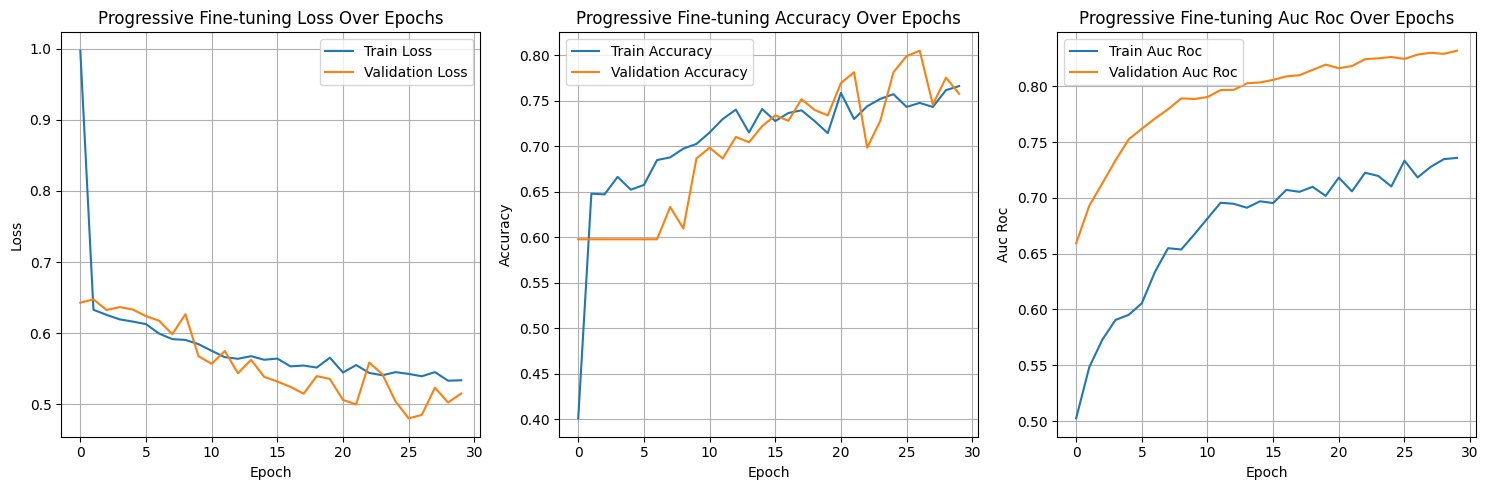

In [ ]:
print("Evaluating the model on the test set after progressive fine-tuning...")
loss_progressive, accuracy_progressive, auc_roc_progressive = model.evaluate(test_generator)

print(f"Test Loss (Progressive FT): {loss_progressive:.4f}")
print(f"Test Accuracy (Progressive FT): {accuracy_progressive:.4f}")
print(f"Test AUC-ROC (Progressive FT): {auc_roc_progressive:.4f}")

# You can also plot the history for this new phase
plot_training_history(history_progressive_fine_tuning, title_prefix="Progressive Fine-tuning")

## 7. Visualize Multi-label Prediction Errors: Confusion Matrix and Classification Report

To better understand where the model is making errors, we'll generate confusion matrices for each label and a comprehensive classification report.

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
Generating confusion matrices for each label...


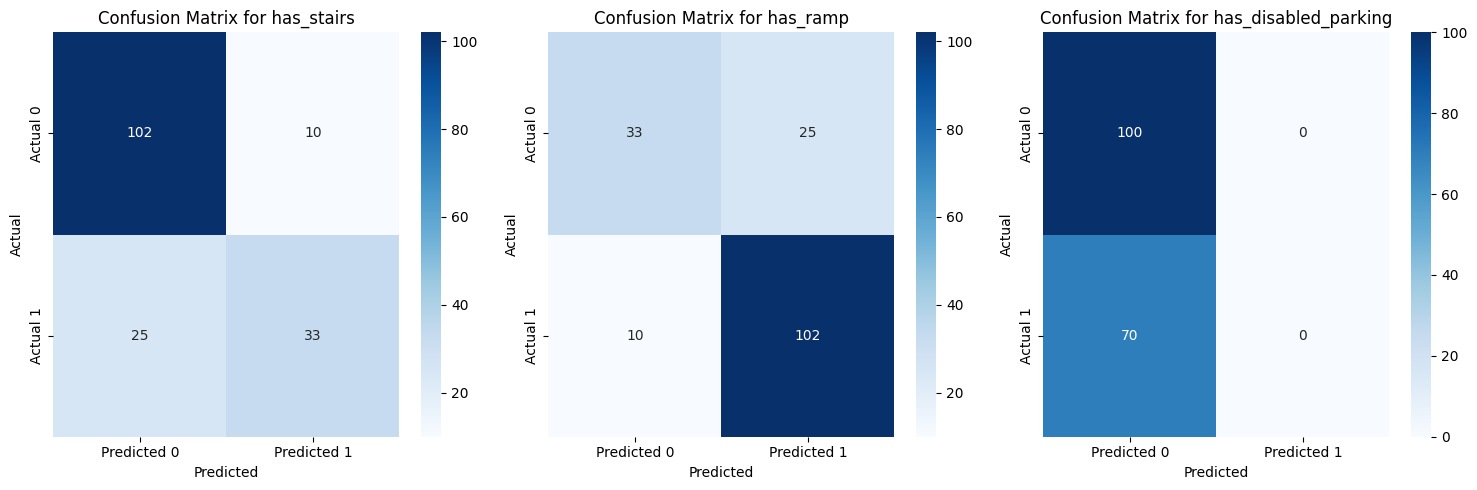


Classification Report:
                      precision    recall  f1-score   support

          has_stairs       0.77      0.57      0.65        58
            has_ramp       0.80      0.91      0.85       112
has_disabled_parking       0.00      0.00      0.00        70

           micro avg       0.79      0.56      0.66       240
           macro avg       0.52      0.49      0.50       240
        weighted avg       0.56      0.56      0.56       240
         samples avg       0.79      0.63      0.68       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reset the test_generator to ensure predictions start from the beginning
test_generator.reset()

# Get true labels
y_true = test_generator.labels

# Get predictions (probabilities) for the test set
y_pred_probs = model.predict(test_generator)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Define the labels (target variables) again for clarity
labels = ['has_stairs', 'has_ramp', 'has_disabled_parking']

print("Generating confusion matrices for each label...")

plt.figure(figsize=(15, 5))
for i, label_name in enumerate(labels):
    cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {label_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_binary, target_names=labels))

## 8. Analyze Class Imbalance for `has_disabled_parking`

Before applying weighted loss, let's look at the distribution of the `has_disabled_parking` label in our datasets to understand the imbalance.

In [ ]:
print("Class Distribution for 'has_disabled_parking' in Training Set:")
display(df_train_expanded['has_disabled_parking'].value_counts())
print("\nClass Distribution for 'has_disabled_parking' in Validation Set:")
display(df_val_expanded['has_disabled_parking'].value_counts())
print("\nClass Distribution for 'has_disabled_parking' in Test Set:")
display(df_test_expanded['has_disabled_parking'].value_counts())

Class Distribution for 'has_disabled_parking' in Training Set:


,count
has_disabled_parking,
False,965
True,389



Class Distribution for 'has_disabled_parking' in Validation Set:


,count
has_disabled_parking,
False,116
True,53



Class Distribution for 'has_disabled_parking' in Test Set:


,count
has_disabled_parking,
False,100
True,70


## 9. Implement Weighted Loss to Address Class Imbalance

Based on the observed class imbalance, especially for `has_disabled_parking`, we will implement a weighted `binary_crossentropy` loss function. This assigns higher penalties for misclassifying samples from underrepresented classes, helping the model pay more attention to them.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf # Ensure tf is imported here

# Calculate class weights for each label individually
class_weights = {}
for i, label_name in enumerate(labels):
    # y_true_label is from df_train_expanded, which is already defined and available
    y_true_label = df_train_expanded[label_name].values

    # Compute weights for the current label
    # Ensure unique_classes are in sorted order if y_true_label has only one class
    unique_classes = np.unique(y_true_label)
    if len(unique_classes) == 1:
        # If only one class exists, assign weight 1 to that class
        weights = {unique_classes[0]: 1.0}
    else:
        weights = compute_class_weight(
            'balanced',
            classes=unique_classes,
            y=y_true_label
        )
        weights = {unique_classes[0]: weights[0], unique_classes[1]: weights[1]}
    class_weights[i] = weights

print("Calculated class weights for each label:")
print(class_weights)

# Define a custom weighted binary crossentropy loss function
def weighted_binary_crossentropy(y_true, y_pred):
    # y_true and y_pred are tensors, need to use tf operations
    y_true = tf.cast(y_true, tf.float32)

    loss_weights = []
    for i in range(NUM_CLASSES):
        # Get weights for the current label (0 for False, 1 for True)
        # Correctly accessing weights using np.False_ and np.True_ as keys
        weight_for_false = class_weights[i][np.False_]
        weight_for_true = class_weights[i][np.True_]

        # Create a weight tensor based on y_true for the current label
        # If y_true is 1, apply weight_for_true, else apply weight_for_false
        weights_i = y_true[:, i] * weight_for_true + (1. - y_true[:, i]) * weight_for_false
        loss_weights.append(weights_i)

    # Stack the weights into a tensor of shape (batch_size, NUM_CLASSES)
    loss_weights_tensor = tf.stack(loss_weights, axis=1)

    # Manually calculate binary crossentropy element-wise
    # Add a small epsilon to prevent log(0) or log(1)
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip predictions to avoid log(0)
    bce = - (y_true * tf.math.log(y_pred) + (1. - y_true) * tf.math.log(1. - y_pred))

    # Apply weights element-wise
    # weighted_bce will also have shape (batch_size, NUM_CLASSES)
    weighted_bce = bce * loss_weights_tensor

    # Sum the weighted loss for each sample across its classes
    # This results in a tensor of shape (batch_size,)
    loss_per_sample = tf.reduce_sum(weighted_bce, axis=1)

    # Keras will then implicitly take the mean of these per-sample losses over the batch
    return loss_per_sample

print("\nCustom weighted_binary_crossentropy loss function defined.")

Calculated class weights for each label:
{0: {np.False_: np.float64(0.7693181818181818), np.True_: np.float64(1.4282700421940928)}, 1: {np.False_: np.float64(1.4282700421940928), np.True_: np.float64(0.7693181818181818)}, 2: {np.False_: np.float64(0.7015544041450777), np.True_: np.float64(1.7403598971722365)}}

Custom weighted_binary_crossentropy loss function defined.


## 10. Re-train with Weighted Loss and Progressive Fine-tuning

Now, we'll re-train the model using the same progressive fine-tuning strategy but with our new `weighted_binary_crossentropy` loss function.

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# First, ensure all layers in the base model are frozen again
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last `unfreeze_layers_count` layers of the base model
unfreeze_layers_count = 30 # Keep the same number as before

print(f"Re-unfreezing the last {unfreeze_layers_count} layers of the base model for weighted progressive fine-tuning...")
for layer in base_model.layers[-unfreeze_layers_count:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Recompile the model with the custom weighted loss function
model.compile(
    optimizer=Adam(learning_rate=0.000001), # Keep the same very low learning rate
    loss=weighted_binary_crossentropy, # Use the custom weighted loss
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc_roc')]
)

print("Model recompiled with weighted loss for progressive fine-tuning. Starting training...")

history_weighted_progressive_fine_tuning = model.fit(
    train_generator,
    epochs=30, # Increased epochs as LR is very low, relying on EarlyStopping
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), # Increased patience
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-7)
    ]
)

print("Weighted progressive fine-tuning phase complete.")

Re-unfreezing the last 30 layers of the base model for weighted progressive fine-tuning...
Model recompiled with weighted loss for progressive fine-tuning. Starting training...
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7304 - auc_roc: 0.7250 - loss: 1.8555 - val_accuracy: 0.7929 - val_auc_roc: 0.8233 - val_loss: 1.7244 - learning_rate: 1.0000e-06
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7459 - auc_roc: 0.7321 - loss: 1.8040 - val_accuracy: 0.7988 - val_auc_roc: 0.8215 - val_loss: 1.6982 - learning_rate: 1.0000e-06
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7437 - auc_roc: 0.7361 - loss: 1.7769 - val_accuracy: 0.7988 - val_auc_roc: 0.8239 - val_loss: 1.7032 - learning_rate: 1.0000e-06
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7230 - auc_roc: 0.7280 - loss: 1.7867 - val_accuracy: 0.7929 - val_auc_roc: 0.8236 - val_loss: 1.6744 - learning_rate: 1.0000e-06
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/s

## 11. Re-evaluate the Model After Weighted Progressive Fine-tuning

Let's evaluate the performance of our model with weighted loss on the test set, paying close attention to the `has_disabled_parking` metric.

Evaluating the model on the test set after weighted progressive fine-tuning...
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8294 - auc_roc: 0.8185 - loss: 1.6229
Test Loss (Weighted Progressive FT): 1.6229
Test Accuracy (Weighted Progressive FT): 0.8294
Test AUC-ROC (Weighted Progressive FT): 0.8185
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

Classification Report (Weighted Progressive FT):
                      precision    recall  f1-score   support

          has_stairs       0.73      0.78      0.75        58
            has_ramp       0.88      0.87      0.87       112
has_disabled_parking       0.51      0.66      0.57        70

           micro avg       0.71      0.78      0.75       240
           macro avg       0.70      0.77      0.73       240
        weighted avg       0.73      0.78      0.76       240
         samples avg       0.72      0.79      0.72       240



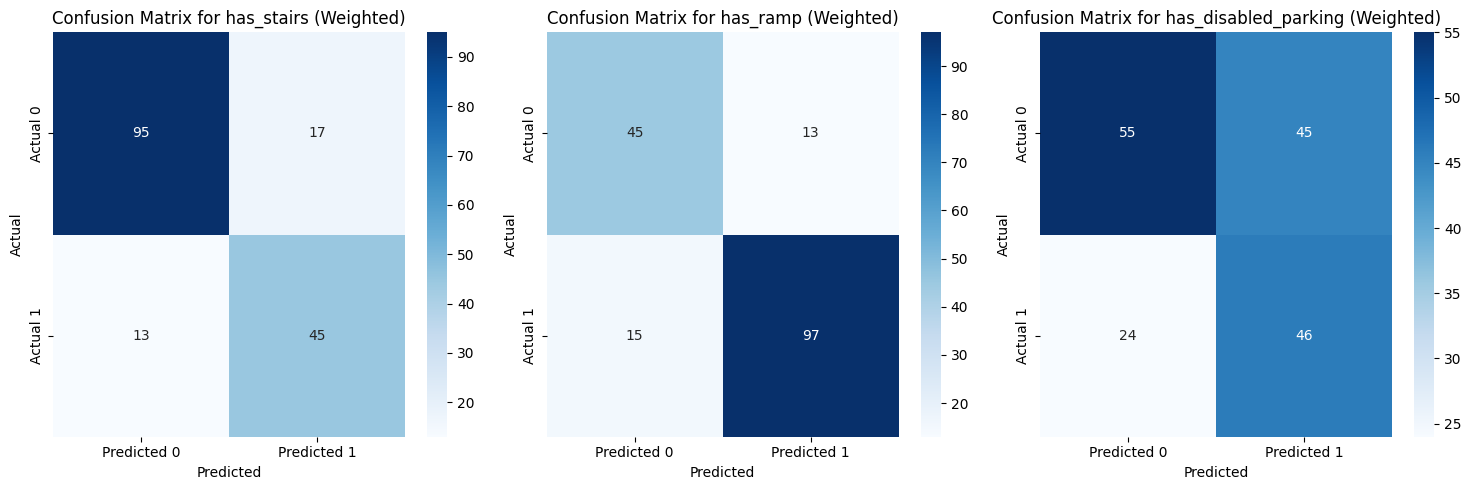

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Evaluating the model on the test set after weighted progressive fine-tuning...")
loss_weighted, accuracy_weighted, auc_roc_weighted = model.evaluate(test_generator)

print(f"Test Loss (Weighted Progressive FT): {loss_weighted:.4f}")
print(f"Test Accuracy (Weighted Progressive FT): {accuracy_weighted:.4f}")
print(f"Test AUC-ROC (Weighted Progressive FT): {auc_roc_weighted:.4f}")

# Get true labels and predictions again for classification report
test_generator.reset()
y_true_weighted = test_generator.labels
y_pred_probs_weighted = model.predict(test_generator)
y_pred_binary_weighted = (y_pred_probs_weighted > 0.5).astype(int)

print("\nClassification Report (Weighted Progressive FT):")
print(classification_report(y_true_weighted, y_pred_binary_weighted, target_names=labels))

# Plot Confusion Matrices again
plt.figure(figsize=(15, 5))
for i, label_name in enumerate(labels):
    cm_weighted = confusion_matrix(y_true_weighted[:, i], y_pred_binary_weighted[:, i])

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {label_name} (Weighted)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()